In [20]:
from traceback import extract_stack

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from jupyter_client.jsonutil import squash_dates
from prompt_toolkit.data_structures import Size
from scipy.constants import year

DB = pd.read_csv("DS1.csv")
print(DB)


       Unnamed: 0   fLength    fWidth   fSize   fConc  fConc1     fAsym  \
0               0   28.7967   16.0021  2.6449  0.3918  0.1982   27.7004   
1               1   31.6036   11.7235  2.5185  0.5303  0.3773   26.2722   
2               2  162.0520  136.0310  4.0612  0.0374  0.0187  116.7410   
3               3   23.8172    9.5728  2.3385  0.6147  0.3922   27.2107   
4               4   75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277   
...           ...       ...       ...     ...     ...     ...       ...   
19015       19015   21.3846   10.9170  2.6161  0.5857  0.3934   15.2618   
19016       19016   28.9452    6.7020  2.2672  0.5351  0.2784   37.0816   
19017       19017   75.4455   47.5305  3.4483  0.1417  0.0549   -9.3561   
19018       19018  120.5135   76.9018  3.9939  0.0944  0.0683    5.8043   
19019       19019  187.1814   53.0014  3.2093  0.2876  0.1539 -167.3125   

        fM3Long  fM3Trans   fAlpha     fDist class  
0       22.0110   -8.2027  40.0920   81.8828  

In [21]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

DB_Alter1 = DB.copy()
DB_Alter1 = DB_Alter1.drop(columns="Unnamed: 0",)
DB_Alter1 = DB_Alter1.dropna()

estandarizar = ["fLength","fWidth", "fSize","fConc","fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha",]
normalizar = ["fDist"]
# Estandarizar
scaler_std = StandardScaler()
DB_Alter1[estandarizar] = scaler_std.fit_transform(DB_Alter1[estandarizar])

# Normalizar
scaler_min = MinMaxScaler(feature_range=(1,10))
DB_Alter1[normalizar] = scaler_min.fit_transform(DB_Alter1[normalizar])
print(DB_Alter1)

        fLength    fWidth     fSize     fConc    fConc1     fAsym   fM3Long  \
0     -0.577226 -0.336804 -0.381130  0.062759 -0.148923  0.541042  0.224818   
1     -0.510969 -0.570027 -0.648595  0.820383  1.471776  0.516919  0.260364   
2      2.568278  6.205858  2.615783 -1.875883 -1.773241  2.044992 -1.478536   
3     -0.694768 -0.687259 -1.029478  1.282069  1.606608  0.532771 -0.333515   
4      0.516622  0.476384  0.711157 -0.347506 -0.284660 -0.020200  0.353086   
...         ...       ...       ...       ...       ...       ...       ...   
19015 -0.752189 -0.613988 -0.442072  1.123433  1.617467  0.330947  0.019196   
19016 -0.573721 -0.843744 -1.180350  0.846640  0.576817  0.699497  0.051761   
19017  0.523923  1.381779  1.318877 -1.305340 -1.445663 -0.084864  0.598262   
19018  1.587757  2.982781  2.473375 -1.564081 -1.324404  0.171204 -2.040597   
19019  3.161459  1.679993  0.813149 -0.507237 -0.549799 -2.752844 -3.509914   

       fM3Trans    fAlpha     fDist class  
0     -

In [22]:
DB_Alter1[estandarizar] = DB_Alter1[estandarizar].round(2)
DB_Alter1[normalizar] = DB_Alter1[normalizar].round(2)

In [23]:
dic_DB_class = {
    "g": 1,
    "h": 0,
}
DB_Alter1["class"] = DB_Alter1["class"].map(dic_DB_class)

In [24]:
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout
import tensorflow as tf


y = DB_Alter1["class"]
x = DB_Alter1.drop("class", axis=1)

#y = DB_Alter["class"]
#x = DB_Alter.drop("class", axis=1)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=32,stratify=y)

print("Características de entrada:", x_train.shape[1])
print("Class:", y.nunique())

model = Sequential()
model.add(Dense(32,input_dim=x_train.shape[1],activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(16,activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(1,activation="sigmoid"))
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])
history = model.fit(x_train,y_train,epochs=100,batch_size=32,validation_split=0.2,verbose=1)

result = model.evaluate(x_test,y_test,verbose=1)
print("Loss:", result[0])
print("Accuracy:", result[1])


Características de entrada: 10
Class: 2
Epoch 1/100


C:\Users\hecto\PycharmProjects\Redes\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7377 - loss: 0.5284 - val_accuracy: 0.7901 - val_loss: 0.4372
Epoch 2/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7878 - loss: 0.4500 - val_accuracy: 0.8074 - val_loss: 0.4097
Epoch 3/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8044 - loss: 0.4276 - val_accuracy: 0.8137 - val_loss: 0.4011
Epoch 4/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8130 - loss: 0.4155 - val_accuracy: 0.8261 - val_loss: 0.3894
Epoch 5/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8252 - loss: 0.3989 - val_accuracy: 0.8299 - val_loss: 0.3773
Epoch 6/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8324 - loss: 0.3890 - val_accuracy: 0.8408 - val_loss: 0.3674
Epoch 7/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8425 - loss: 0.3767 - val_accuracy: 0.8423 - val_loss: 0.3625
Epoch 8/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8443 - loss: 0.3734 - val_accuracy: 0.8468

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 614us/step


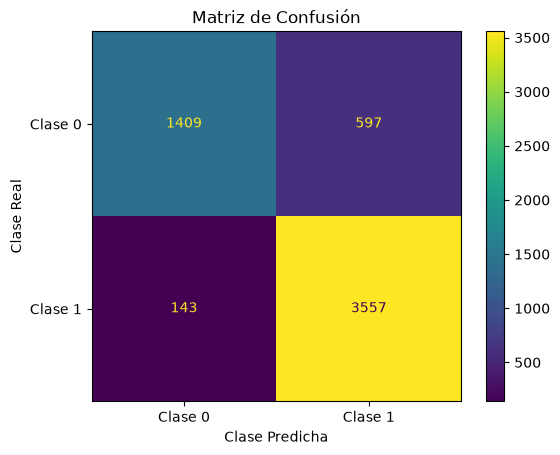

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Predicciones del modelo (Probabilidades entre 0 y 1)
y_pred_probs = model.predict(x_test)

# FIX: Convertir probabilidades a la clase predicha usando un umbral de 0.5
y_pred = (y_pred_probs > 0.5).astype(int)

# Crear matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar matriz
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Clase 0", "Clase 1"]
)

disp.plot(cmap="viridis")

plt.title("Matriz de Confusión")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Real")
plt.show()